# Generate FLUKA input files for T2R and leNuSTORM ring simulation

Generate the FLUKA files for the Pion Transfer line and LEnuSTORM Ring

Uses:
- essbeamsim.py 
- essbeamsim_plots.py
- essbeamsim.yaml

Needs:
Xsuite installation from : https://xsuite.readthedocs.io/en/latest/

Status: 
12.11.2025 : code completed up to the generation of the beam (TR2 and NUSTORM) elements.
        
To do:
- generate the global volumes of the tunnels etc. 

In [1]:
import numpy as np
import pandas as pd

import xobjects as xo
import xtrack as xt

import math

import matplotlib 
import matplotlib.pyplot as plt
import matplotlib.patches as patches


import re
import json
import yaml, pprint
# from dotdict import DotDict as dd

import essnusbsim.helpers as hlp
import essnusbsim.plot_helpers as hplot

import scipy
import scipy.constants

from particle import Particle

print(f' Beam parameters : ')
import os

%run ../InitPlots.py
    
MyPlots().configPlots('')

print_array_with_format = lambda x : ' '.join(f'{v:.5f}' for v in x)
distance2d = lambda x,y : np.sqrt((x[0]-y[0])**2 + (x[1]-y[1])**2)

getcoord = lambda x, ofs: ' '.join(map(str, (np.array(x)+ofs*np.sign(x))*100))


 Beam parameters : 

>>> Running InitPlots.py - Version : 1.02 - 07.03.2023 (IE)
---- running configPlots function 


In [2]:

from pathlib import Path

BASE = Path().resolve().parent

data_path = BASE / "data" 
opt_path = BASE / "data" / "raw"
output_path = BASE / "data" / "intermediate"

paths = {
    "BASE": BASE,
    "data_path": data_path,
    "opt_path": opt_path,
    "output_path": output_path,
}

print("\n" + "=" * 80)
print(f"Starting generate_fulka.ipynb")
print("=" * 80 + "\n")

print("\nDefined paths:")
for name, value in paths.items():
    print(f"  {name:<15} {value}")



Starting generate_fulka.ipynb


Defined paths:
  BASE            /Users/iliasefthymiopoulos/Work/esslenustorm
  data_path       /Users/iliasefthymiopoulos/Work/esslenustorm/data
  opt_path        /Users/iliasefthymiopoulos/Work/esslenustorm/data/raw
  output_path     /Users/iliasefthymiopoulos/Work/esslenustorm/data/intermediate


In [3]:
with open(f'{data_path}/essbeamsim.yaml','r') as fin:
    config = hlp.DotDict(yaml.safe_load(fin))
pprint.pprint(config)

{'beam_size': 0.1,
 'd1_aperture_margin': 1.2,
 'd_shield': 4.0,
 'h_decay_tunnel': [-6.5, 6.5],
 'h_ring_tunnel': 4,
 'h_target_cavern': [-3.5, 3.5],
 'h_tline_tunnel': 4,
 'l_decay_tunnel': 60,
 'magnet_width': 0.8,
 'mparking_radious': 10,
 'mparking_start': [0, 0, -101],
 'nustormoptics': 'ring-mb3.json',
 'qaperture_x': 0.15,
 'qaperture_y': 0.15,
 'r_decay_pipe': 2.5,
 'ring_walls': 2,
 'ss_to_lemmond': 50,
 't2r': {'l_bend_end': 0.35,
         'l_bend_woke': 0.5,
         'l_qfl_end': 0.2,
         'l_qfl_h': 0.9,
         'l_qfl_w': 0.9,
         'l_quad_end': 0.2,
         'l_quad_h': 0.6,
         'l_quad_w': 0.6,
         'l_vac': 0.1},
 't2r_start': [0, 2.0],
 't2rend_to_inj': [-2, 6.0],
 't2roptics': '20251216-t2r-ie.json',
 't2rstart_to_inj': [-9.08278251237319, 23.1539181004073],
 't_tline_tunnel': 2,
 'target_len': 0.78,
 'target_radious': 0.015,
 'thbox_x': [-1, 1],
 'thbox_y': [-1, 1],
 'thbox_z': [-0.1, 1],
 'trg_to_lblnd': 320,
 'w_decay_tunnel': [-7, 7],
 'w_ring_t

## Reminder on Beam Parameters

Reminder on beam energy and momentum

$E = E_{kin} + E_0(=\mathrm{m}_0\, c^2)$

$E^2 = E_0^2 + P^2 \Rightarrow P^2 = \sqrt{E^2 - E_0^2} \Rightarrow P = \sqrt{(E-E_0)(E+E_0)}$

$P = \sqrt{E_{kin}(E_{kin}+2E_0)}$

$\beta\gamma = P/\mathrm{m}_0$

$\gamma = \sqrt{(\beta\gamma)^2+1}$

$\beta = \beta\gamma/\gamma$

In [4]:
pion = Particle.from_name('pi+')
muon = Particle.from_name('mu+')
proton = Particle.from_name('p')

# particle mass [MeV/c2] --> convert to [GeV/c2]
pmass_gev = proton.mass/1000
pimass_gev = pion.mass/1000
mumass_gev = muon.mass/1000

# print(xx.mass, xx.lifetime*1.0e-9)

# primary proton beam
pbeam_ekk_gev = 2.5
pbeam_etot = pbeam_ekk_gev + pmass_gev
pbeam_mom_gev = np.sqrt(pbeam_ekk_gev*(pbeam_ekk_gev+2*pmass_gev))
pbeam_beta, pbeam_gamma = hlp.particle_beta_gamma('p', pbeam_mom_gev)

# pion beam
beam_momentum = 0.7
pion_beta, pion_gamma = hlp.particle_beta_gamma('pi+', beam_momentum)
pion_decay_length = pion.lifetime*1.0e-9*scipy.constants.c*pion_gamma

# muon beam
muon_momentum = 0.4
muon_beta, muon_gamma = hlp.particle_beta_gamma('mu+', muon_momentum)
muon_lifetime = muon.lifetime*1.0e-9*muon_gamma  # lifetime is given in ns
muon_decay_length = muon_lifetime*scipy.constants.c

muon_momentum_max = 0.7
muon_beta_max, muon_gamma_max = hlp.particle_beta_gamma('mu+', muon_momentum_max)
muon_lifetime_max = muon.lifetime*1.0e-9*muon_gamma_max  # lifetime is given in ns
muon_decay_length_max = muon_lifetime_max*scipy.constants.c

print(f''' Paramters (units in GeV)
            primary proton beam:
                {pbeam_ekk_gev=}
                {pbeam_etot=:.5f}
                {pbeam_mom_gev=:.5f}
                {pbeam_gamma=:.5f}
                {pbeam_beta=:.5f}
            extracted pion beam:
                {beam_momentum=}
                {pion_gamma=:.5f} [s]
                {pion_decay_length=:.5f} [m]
            stored muon beam:
                {muon_momentum=}
                {muon_beta=:.5f}
                {muon_gamma=:.5f}
                {muon_lifetime=:.5f} [s], {muon_lifetime/1.0e-6:.5f} [us]
                {muon_decay_length=:.5f} [m]
                
                {muon_momentum_max=}
                {muon_beta_max=:.5f}
                {muon_gamma_max=:.5f}
                {muon_lifetime_max=:.5f} [s], {muon_lifetime_max/1.0e-6:.5f} [us]
                {muon_decay_length_max=:.5f} [m]
        ''')

 Paramters (units in GeV)
            primary proton beam:
                pbeam_ekk_gev=2.5
                pbeam_etot=3.43827
                pbeam_mom_gev=3.30777
                pbeam_gamma=3.66447
                pbeam_beta=0.96205
            extracted pion beam:
                beam_momentum=0.7
                pion_gamma=5.11411 [s]
                pion_decay_length=39.91268 [m]
            stored muon beam:
                muon_momentum=0.4
                muon_beta=0.96684
                muon_gamma=3.91563
                muon_lifetime=0.00001 [s], 8.60257 [us]
                muon_decay_length=2578.98569 [m]
                
                muon_momentum_max=0.7
                muon_beta_max=0.98880
                muon_gamma_max=6.70017
                muon_lifetime_max=0.00001 [s], 14.72015 [us]
                muon_decay_length_max=4412.98966 [m]
        


## Load the LEnuSTORM lattice

In [5]:

def get_kvalue(r):
    if r.element_type == 'Bend':
        return r.element.k0
    elif r.element_type == 'Quadrupole' :
        return r.element.k1
    else:
        return 0
    
def get_flukadf(df, lineid='TL', verbose=False):
    ''' Prepare the beam elements DF for FLUKA'''

    df['length'] = df['s_end'] - df['s_start']
    df['kvalue'] = df.apply(lambda x: get_kvalue(x), axis=1)

    mask = ((df.element_type != 'Drift') & (df.kvalue != 0)) | (df.element_type == 'Marker')

    df = df[mask].copy()
    
    df['length_cm'] = df['length'].apply(lambda x: x*100)
    df['X_cm']      = df['X'].apply(lambda x: x*100)
    df['Y_cm']      = df['Y'].apply(lambda x: x*100)
    df['Z_cm']      = df['Z'].apply(lambda x: x*100)
    df['theta_deg'] = df['theta'].apply(lambda x: x*180/np.pi)
    
    df['belement'] = lineid + df["name"].str[:2] + (df.groupby(df["name"].str[:2]).cumcount() + 1).astype(str)
    df['model'] = np.select(
        [
            df['element_type'] == 'Bend',
            df['element_type'] == 'Quadrupole'
        ],
        [
            'MB' + (df['length'] * 100).round().astype(int).astype(str),
            'QM' + (df['length'] * 100).round().astype(int).astype(str)
        ],
        default= np.nan
        )
    if verbose:
        mask = df.element_type.isin(['Bend', 'Quadrupole'])
        print(f' -- belements: {set(df["belement"][mask].unique())}')
        print(f' -- models: {set(df["model"][mask].unique())}')

    return df

In [6]:
# fin = '../src/ring-mb3.json'
fin = opt_path / config.nustormoptics
fin = opt_path / 'full_ring-600.json'

nustormring = xt.Line.from_json(fin)

add_inj_marker = False
if add_inj_marker : 
    
    env = nustormring.env
    env.new('t2rinj', xt.Marker)

    # --- add injection marker
    nustormring.insert([
        env.place('t2rinj', at=100.325)
    ])

    # --- cycle the ring to start from a given element
    nustormring.cycle(name_first_element='t2rinj', inplace=True)

nustormring_df = nustormring.get_table(attr=True).to_pandas()
nustormring_df['kvalue'] = nustormring_df.apply(lambda x: hlp.get_kvalue(x), axis=1)

ringsrv_df = nustormring.survey().to_pandas()
ringsrv_df = ringsrv_df.rename(columns={'name':'name_srv'})
display(ringsrv_df[ringsrv_df.element_type != 'Drift'].head(40))

nustormring_df = nustormring_df.join(ringsrv_df[['name_srv','X','Y','Z','theta','phi','psi']], how='outer')
assert nustormring_df.isna().any().any(), 'NaN values found in the dataframe' # there should be no NaN if dataframes of same length

nustormring_elements_df = hlp.get_flukadf(nustormring_df, lineid='NS', verbose=True)
display(nustormring_elements_df.head(20))

Loading line from dict:   0%|          | 0/596 [00:00<?, ?it/s]

Done loading line from dict.           


,X,Y,Z,theta,phi,psi,ex,ey,ez,XYZ,E_matrix,p0,W,name_srv,element_type,isthick,prototype,drift_length,length,s
0,0.0,0.0,0.000,0.0,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 0.0]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...","[0.0, 0.0, 0.0]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...",start_cell.S.0,Marker,False,start_cell.S,0.000,0.000,0.000
1,0.0,0.0,0.000,0.0,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 0.0]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...","[0.0, 0.0, 0.0]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...",QF.S.0,Quadrupole,True,QF.S,0.125,0.125,0.000
3,0.0,0.0,1.225,0.0,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 1.225]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...","[0.0, 0.0, 1.225]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...",QD.S.0,Quadrupole,True,QD.S,0.125,0.125,1.225
4,0.0,0.0,1.350,0.0,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 1.35]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...","[0.0, 0.0, 1.35]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...",mid_cell.S.0,Marker,False,mid_cell.S,0.000,0.000,1.350
5,0.0,0.0,1.350,0.0,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 1.35]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...","[0.0, 0.0, 1.35]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...",mid_cell.S.1,Marker,False,mid_cell.S,0.000,0.000,1.350
6,0.0,0.0,1.350,0.0,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 1.35]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...","[0.0, 0.0, 1.35]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...",QD.S.1,Quadrupole,True,QD.S,0.125,0.125,1.350
8,0.0,0.0,2.575,0.0,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 2.575]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...","[0.0, 0.0, 2.575]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...",QF.S.1,Quadrupole,True,QF.S,0.125,0.125,2.575
9,0.0,0.0,2.700,0.0,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 2.7]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...","[0.0, 0.0, 2.7]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...",start_cell.S.1,Marker,False,start_cell.S,0.000,0.000,2.700
10,0.0,0.0,2.700,0.0,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 2.7]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...","[0.0, 0.0, 2.7]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...",start_cell.S.2,Marker,False,start_cell.S,0.000,0.000,2.700
11,0.0,0.0,2.700,0.0,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 2.7]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...","[0.0, 0.0, 2.7]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...",QF.S.2,Quadrupole,True,QF.S,0.125,0.125,2.700


 -- belements: {'NSQD60', 'NSQD6', 'NSB.2', 'NSQF104', 'NSQD119', 'NSQD1', 'NSQD124', 'NSQF33', 'NSQF5', 'NSQF113', 'NSQF6', 'NSQF45', 'NSQD126', 'NSQF100', 'NSQD8', 'NSQF37', 'NSQF141', 'NSQF93', 'NSQF64', 'NSQF101', 'NSQF2', 'NSQF116', 'NSQD43', 'NSQD76', 'NSQF143', 'NSQD112', 'NSQD137', 'NSQD61', 'NSQF47', 'NSQD41', 'NSQF43', 'NSQF22', 'NSQD129', 'NSQD101', 'NSQF60', 'NSQF107', 'NSQF115', 'NSQD42', 'NSQD83', 'NSQF127', 'NSQF111', 'NSB.17', 'NSQF126', 'NSQD134', 'NSQD38', 'NSQD107', 'NSB.9', 'NSQF145', 'NSQF69', 'NSQD23', 'NSQF105', 'NSQF142', 'NSQD82', 'NSQF150', 'NSB.13', 'NSQD94', 'NSQD84', 'NSQF28', 'NSQD54', 'NSQD114', 'NSQF135', 'NSQD25', 'NSQD9', 'NSQF120', 'NSQD105', 'NSQD35', 'NSQD17', 'NSQF4', 'NSQD90', 'NSQD46', 'NSQD109', 'NSQF112', 'NSQD44', 'NSQD30', 'NSQD10', 'NSQF82', 'NSQF109', 'NSQF148', 'NSQD49', 'NSQF58', 'NSQF96', 'NSQD16', 'NSQF117', 'NSQD133', 'NSB.8', 'NSQF49', 'NSB.18', 'NSQD32', 'NSQF97', 'NSQF71', 'NSQF15', 'NSQD122', 'NSQD145', 'NSQD75', 'NSQF134', 'NSQF10

,s,element_type,name,isthick,isreplica,parent_name,parent_type,prototype,iscollective,s_start,...,theta,phi,psi,length_cm,X_cm,Y_cm,Z_cm,theta_deg,belement,model
0,0.000,Marker,start_cell.S.0,False,False,None,None,start_cell.S,False,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NSst1,NaN
1,0.000,Quadrupole,QF.S.0,True,False,None,None,QF.S,False,0.000,...,0.0,0.0,0.0,12.5,0.0,0.0,0.0,0.0,NSQF1,QM12
3,1.225,Quadrupole,QD.S.0,True,False,None,None,QD.S,False,1.225,...,0.0,0.0,0.0,12.5,0.0,0.0,122.5,0.0,NSQD1,QM12
4,1.350,Marker,mid_cell.S.0,False,False,None,None,mid_cell.S,False,1.350,...,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,NSmi1,NaN
5,1.350,Marker,mid_cell.S.1,False,False,None,None,mid_cell.S,False,1.350,...,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,NSmi2,NaN
6,1.350,Quadrupole,QD.S.1,True,False,None,None,QD.S,False,1.350,...,0.0,0.0,0.0,12.5,0.0,0.0,135.0,0.0,NSQD2,QM12
8,2.575,Quadrupole,QF.S.1,True,False,None,None,QF.S,False,2.575,...,0.0,0.0,0.0,12.5,0.0,0.0,257.5,0.0,NSQF2,QM12
9,2.700,Marker,start_cell.S.1,False,False,None,None,start_cell.S,False,2.700,...,0.0,0.0,0.0,0.0,0.0,0.0,270.0,0.0,NSst2,NaN
10,2.700,Marker,start_cell.S.2,False,False,None,None,start_cell.S,False,2.700,...,0.0,0.0,0.0,0.0,0.0,0.0,270.0,0.0,NSst3,NaN
11,2.700,Quadrupole,QF.S.2,True,False,None,None,QF.S,False,2.700,...,0.0,0.0,0.0,12.5,0.0,0.0,270.0,0.0,NSQF3,QM12


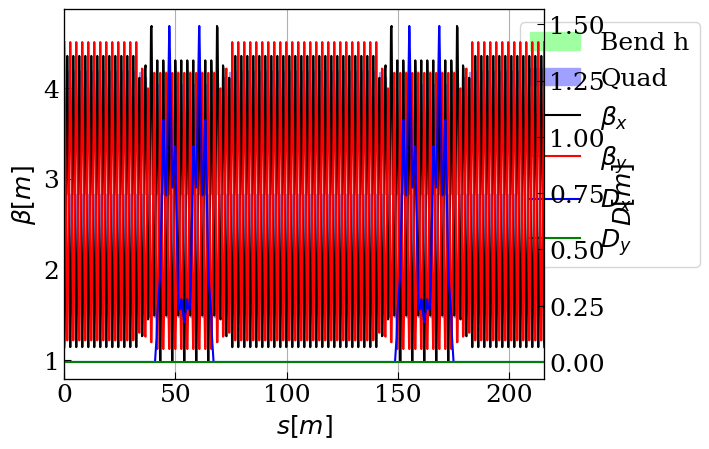

In [7]:
nustormring.set_particle_ref('proton', p0c=0.6e9)
_tt = nustormring.twiss4d()
_tt.plot()

In [8]:
if 0 : 
    _nustormtbl = nustormring.get_table()
    print(_nustormtbl.cols)
    # _nustormtbl.show()
    _nustormtbl.rows[_nustormtbl.element_type=='Bend']


/opt/anaconda3/envs/essnusb/lib/python3.13/site-packages/xplt/hooks.py:31: RuntimeWarning: Failed to register formatters with pint: No module named 'pint'
  warnings.warn(f"Failed to register formatters with pint: {e}", RuntimeWarning)
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


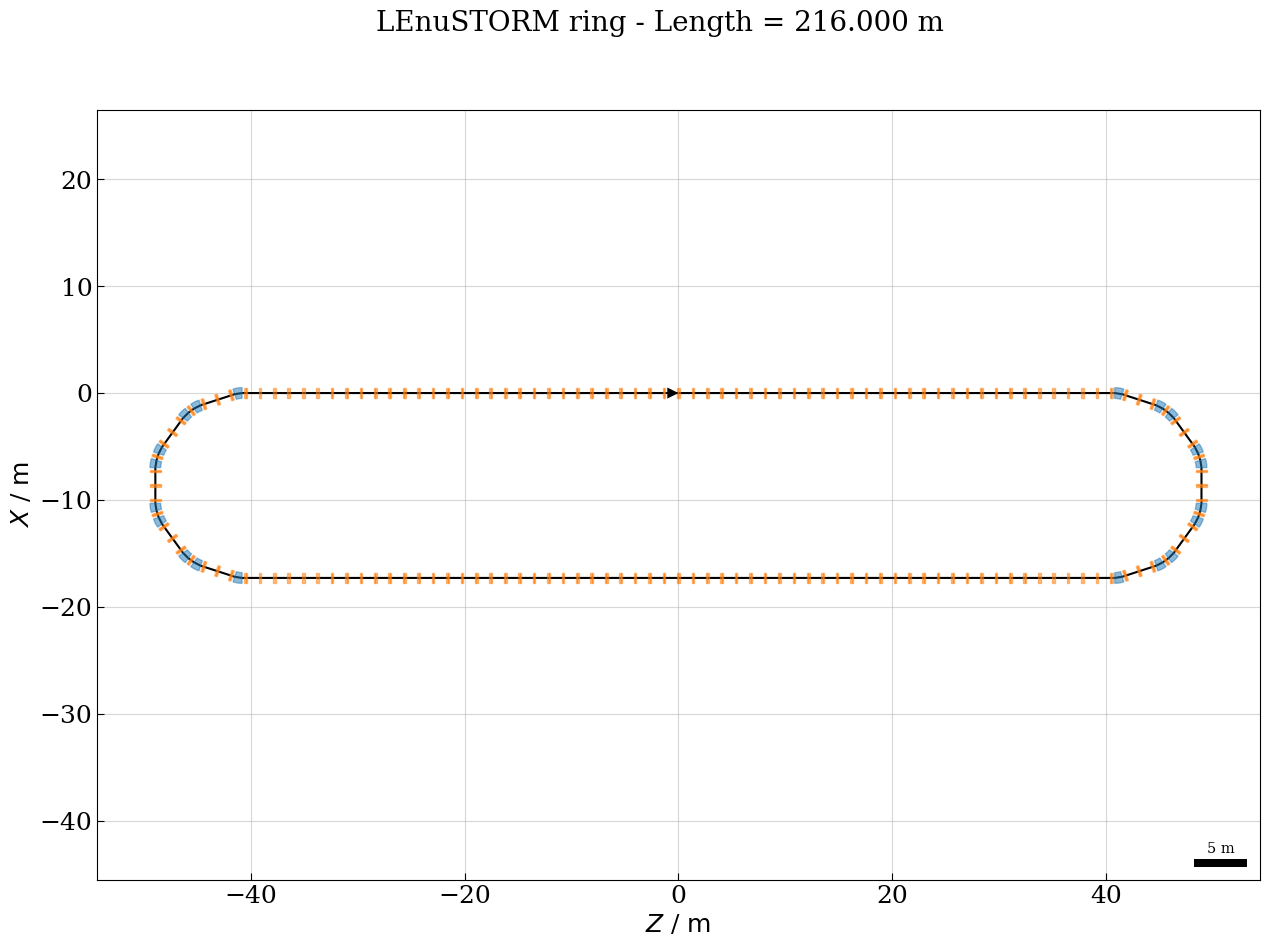

In [9]:
if True:
    import xplt
    plot = xplt.FloorPlot(nustormring.survey(), figsize=(15,10))
    plot.add_scale()
    plot.title(f'LEnuSTORM ring - Length = {nustormring.get_length():.3f} m')
    plot.ax.set(ylim=(-20, 1))
    
    
    # plot2 = xplt.KnlPlot(nustormring, figsize=(7, 3))
    # plot2.ax.set(ylim=(-1, 1));
    
    

### Load nuSTORM ring sub-lines

- arc = 5 * arc_fodo
- half_straight = 12 * straight_fodo
- full_ring = 2 * ( straight + matching_cell + arc - matching_cell + straight)  # or in any order you want.


In [10]:
def detect_common_elements(line1, line2):
    common = set(line1.element_names) & set(line2.element_names)
    print(f' --- common elements between {line1} and {line2} : {len(common)}')
    for nn in sorted(common):
        print(f' in {line1} : {line1[nn]}')
        print(f' in {line2} : {line2[nn]}')

In [11]:
nustorm_env = xt.Environment()

segment_files = {
    'arc_cell'      : 'one-alternating-bend_arc_fodo-600.json',
    'straight_cell' : 'one-alternating-bend_straight_fodo-600.json',
    'matching_cell' : 'one-alternating-bend_matching_cell-S2A-600.json',
}

# each segment keeps its own isolated environment
nustorm_ring_segments = {}
for name, fname in segment_files.items():
    nustorm_ring_segments[name] = xt.Line.from_json(opt_path / fname)

# derived segments (stay in same env as source)
nustorm_ring_segments['arc']           = 5  * nustorm_ring_segments['arc_cell']
nustorm_ring_segments['half_straight'] = 12 * nustorm_ring_segments['straight_cell']

# merge into nustorm_env ONLY for combination
for sname in ['half_straight', 'matching_cell', 'arc']:
    seg = nustorm_ring_segments[sname]
    nustorm_env._element_dict.update(seg.env._element_dict)
    seg._env = nustorm_env


half_ring = nustorm_env.new_line(components=[
    nustorm_ring_segments['half_straight'],
    nustorm_ring_segments['matching_cell'],
    nustorm_ring_segments['arc'],
    -nustorm_ring_segments['matching_cell'],
    nustorm_ring_segments['half_straight'],
])
full_ring = 2* half_ring

print(f' --- half_ring  length = {half_ring.get_length():.3f} m')
print(f' --- full_ring  length = {full_ring.get_length():.3f} m')

assert nustormring.get_length() == full_ring.get_length(), 'length of the two rings do not match'



Loading line from dict:   0%|          | 0/7 [00:00<?, ?it/s]

Done loading line from dict.           
Done loading line from dict.           
Done loading line from dict.           


Loading line from dict:   0%|          | 0/5 [00:00<?, ?it/s]

Done loading line from dict.           
Done loading line from dict.           
Done loading line from dict.           


Loading line from dict:   0%|          | 0/9 [00:00<?, ?it/s]

Done loading line from dict.           
 --- half_ring  length = 108.000 m
 --- full_ring  length = 216.000 m


name                  s_start      s_center         s_end           k1l
start_cell.S::0             0             0             0             0
QF.S::0                     0        0.0625         0.125     -0.461419
||drift_3::0            0.125         0.675         1.225             0
QD.S::0                 1.225        1.2875          1.35      0.473919
mid_cell.S::0            1.35          1.35          1.35             0
mid_cell.S::1            1.35          1.35          1.35             0
QD.S::1                  1.35        1.4125         1.475      0.473919
||drift_3::1            1.475         2.025         2.575             0
QF.S::1                 2.575        2.6375           2.7     -0.461419
start_cell.S::1           2.7           2.7           2.7             0
_end_point                2.7           2.7           2.7             0
None


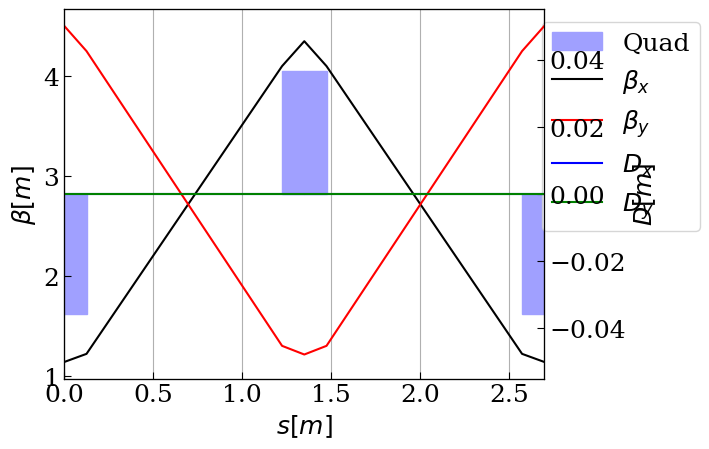

In [12]:
_aline = nustorm_ring_segments['straight_cell']
_aline.set_particle_ref('proton', p0c=0.6e9)
_tt = _aline.twiss4d()
print(_aline.get_table(attr=True).show(cols=['name','s_start','s_center','s_end','k1l']))

_tt.plot()

## Load the T2R beam transfer line

In [13]:
# fin = '../src/transfer-line-1050.json'
fin = '../src/20250922-t2r-line.json'
fin = opt_path / config.t2roptics
t2rline = xt.Line.from_json(fin)

_t2renv = t2rline.env
_t2renv.new('t2rend', xt.Marker)
t2rline.insert([
    _t2renv.place('t2rend', at=t2rline.get_length())
    ])


t2rline_df = t2rline.get_table(attr=True).to_pandas()
t2rline_df['kvalue'] = t2rline_df.apply(lambda x: hlp.get_kvalue(x), axis=1)

t2rsrv_df = t2rline.survey().to_pandas()
t2rsrv_df = t2rsrv_df.rename(columns={'name':'name_srv'})
display(t2rsrv_df[t2rsrv_df.element_type != 'Drift'].head(40))


t2rline_df = t2rline_df.join(t2rsrv_df[['name_srv','X','Y','Z','theta','phi','psi']], how='outer')
assert t2rline_df.isna().any().any(), 'NaN values found in the dataframe' # there should be no NaN if dataframes of same length

t2rline_elements_df = hlp.get_flukadf(t2rline_df, lineid='TL', verbose=True)
display(t2rline_elements_df.head())

Loading line from dict:   0%|          | 0/31 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/31 [00:00<?, ?it/s]

,X,Y,Z,theta,phi,psi,ex,ey,ez,XYZ,E_matrix,p0,W,name_srv,element_type,isthick,prototype,drift_length,length,s
0,0.000000,0.0,0.000000,0.000000,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 0.0]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...","[0.0, 0.0, 0.0]","[[1.0, -0.0, 0.0], [0.0, 1.0, 0.0], [-0.0, 0.0...",mbtl0.0,Bend,True,None,1.500000,1.500000,0.000000
2,-0.523984,0.0,1.909403,-0.428280,0.0,0.0,"[0.9096813403136949, 0.0, 0.41530694562585835]","[0.0, 1.0, 0.0]","[-0.41530694562585835, 0.0, 0.9096813403136949]","[-0.5239837401250507, 0.0, 1.9094034103779414]","[[0.9096813403136949, 0.0, -0.4153069456258583...","[-0.5239837401250507, 0.0, 1.9094034103779414]","[[0.9096813403136949, 0.0, -0.4153069456258583...",mq_t2r.0,Quadrupole,True,None,0.800000,0.800000,2.000000
4,-1.063883,0.0,3.091989,-0.428280,0.0,0.0,"[0.9096813403136949, 0.0, 0.41530694562585835]","[0.0, 1.0, 0.0]","[-0.41530694562585835, 0.0, 0.9096813403136949]","[-1.0638827694386668, 0.0, 3.0919891527857453]","[[0.9096813403136949, 0.0, -0.4153069456258583...","[-1.0638827694386668, 0.0, 3.0919891527857453]","[[0.9096813403136949, 0.0, -0.4153069456258583...",mq_t2r.1,Quadrupole,True,None,0.800000,0.800000,3.300000
6,-1.603782,0.0,4.274575,-0.428280,0.0,0.0,"[0.9096813403136949, 0.0, 0.41530694562585835]","[0.0, 1.0, 0.0]","[-0.41530694562585835, 0.0, 0.9096813403136949]","[-1.6037817987522827, 0.0, 4.274574895193549]","[[0.9096813403136949, 0.0, -0.4153069456258583...","[-1.6037817987522827, 0.0, 4.274574895193549]","[[0.9096813403136949, 0.0, -0.4153069456258583...",mq_t2r.2,Quadrupole,True,None,0.800000,0.800000,4.600000
8,-2.143681,0.0,5.457161,-0.428280,0.0,0.0,"[0.9096813403136949, 0.0, 0.41530694562585835]","[0.0, 1.0, 0.0]","[-0.41530694562585835, 0.0, 0.9096813403136949]","[-2.1436808280658988, 0.0, 5.457160637601352]","[[0.9096813403136949, 0.0, -0.4153069456258583...","[-2.1436808280658988, 0.0, 5.457160637601352]","[[0.9096813403136949, 0.0, -0.4153069456258583...",mbtl0.1,Bend,True,None,1.500000,1.500000,5.900000
10,-3.308277,0.0,6.885425,-0.856560,0.0,0.0,"[0.6550402818298406, 0.0, 0.7555939578770352]","[0.0, 1.0, 0.0]","[-0.7555939578770352, 0.0, 0.6550402818298406]","[-3.308277003741486, 0.0, 6.885424671735198]","[[0.6550402818298406, 0.0, -0.7555939578770352...","[-3.308277003741486, 0.0, 6.885424671735198]","[[0.6550402818298406, 0.0, -0.7555939578770352...",mq_t2r.3,Quadrupole,True,None,0.779348,0.779348,7.760970
12,-4.287806,0.0,7.734599,-0.856560,0.0,0.0,"[0.6550402818298406, 0.0, 0.7555939578770352]","[0.0, 1.0, 0.0]","[-0.7555939578770352, 0.0, 0.6550402818298406]","[-4.287806262177562, 0.0, 7.734599171898367]","[[0.6550402818298406, 0.0, -0.7555939578770352...","[-4.287806262177562, 0.0, 7.734599171898367]","[[0.6550402818298406, 0.0, -0.7555939578770352...",mq_t2r.4,Quadrupole,True,None,0.779348,0.779348,9.057339
14,-5.195960,0.0,8.521896,-0.856560,0.0,0.0,"[0.6550402818298406, 0.0, 0.7555939578770352]","[0.0, 1.0, 0.0]","[-0.7555939578770352, 0.0, 0.6550402818298406]","[-5.19595954565986, 0.0, 8.52189633931927]","[[0.6550402818298406, 0.0, -0.7555939578770352...","[-5.19595954565986, 0.0, 8.52189633931927]","[[0.6550402818298406, 0.0, -0.7555939578770352...",mq_t2r.5,Quadrupole,True,None,0.779348,0.779348,10.259246
16,-6.104113,0.0,9.309194,-0.856560,0.0,0.0,"[0.6550402818298406, 0.0, 0.7555939578770352]","[0.0, 1.0, 0.0]","[-0.7555939578770352, 0.0, 0.6550402818298406]","[-6.104112829142157, 0.0, 9.309193506740172]","[[0.6550402818298406, 0.0, -0.7555939578770352...","[-6.104112829142157, 0.0, 9.309193506740172]","[[0.6550402818298406, 0.0, -0.7555939578770352...",mq_t2r.6,Quadrupole,True,None,0.779348,0.779348,11.461152
18,-7.049845,0.0,10.129069,-0.856560,0.0,0.0,"[0.6550402818298406, 0.0, 0.7555939578770352]","[0.0, 1.0, 0.0]","[-0.7555939578770352, 0.0, 0.6550402818298406]","[-7.049845092860305, 0.0, 10.129068681896515]","[[0.6550402818298406, 0.0, -0.7555939578770352...","[-7.049845092860305, 0.

 -- belements: {'TLmq5', 'TLmq1', 'TLmb2', 'TLmq9', 'TLmb4', 'TLmq6', 'TLmq4', 'TLmb3', 'TLmq11', 'TLmq8', 'TLmq7', 'TLmq2', 'TLmq3', 'TLmb1', 'TLmq10'}
 -- models: {'MB150', 'MB125', 'QM78', 'QM80'}


,s,element_type,name,isthick,isreplica,parent_name,parent_type,prototype,iscollective,s_start,...,theta,phi,psi,length_cm,X_cm,Y_cm,Z_cm,theta_deg,belement,model
0,0.0,Bend,mbtl0.0,True,False,None,None,None,False,0.0,...,0.00000,0.0,0.0,150.0,0.000000,0.0,0.000000,0.000000,TLmb1,MB150
2,2.0,Quadrupole,mq_t2r.0,True,False,None,None,None,False,2.0,...,-0.42828,0.0,0.0,80.0,-52.398374,0.0,190.940341,-24.538648,TLmq1,QM80
4,3.3,Quadrupole,mq_t2r.1,True,False,None,None,None,False,3.3,...,-0.42828,0.0,0.0,80.0,-106.388277,0.0,309.198915,-24.538648,TLmq2,QM80
6,4.6,Quadrupole,mq_t2r.2,True,False,None,None,None,False,4.6,...,-0.42828,0.0,0.0,80.0,-160.378180,0.0,427.457490,-24.538648,TLmq3,QM80
8,5.9,Bend,mbtl0.1,True,False,None,None,None,False,5.9,...,-0.42828,0.0,0.0,150.0,-214.368083,0.0,545.716064,-24.538648,TLmb2,MB150


In [14]:
t2rline_df.columns

Index(['s', 'element_type', 'name', 'isthick', 'isreplica', 'parent_name',
       'parent_type', 'prototype', 'iscollective', 's_start',
       ...
       '_parent_main_is_skew', 'env_name', 'kvalue', 'name_srv', 'X', 'Y', 'Z',
       'theta', 'phi', 'psi'],
      dtype='object', length=191)

In [15]:
cols = ['s', 'element_type', 'name', 'length', 's_start', 's_center', 's_end', 'X', 'Y', 'Z', 'theta']
display(t2rline_df[cols].head())
display(t2rline_df[cols].tail())

,s,element_type,name,length,s_start,s_center,s_end,X,Y,Z,theta
0,0.0,Bend,mbtl0.0,1.5,0.0,0.75,1.5,0.000000,0.0,0.000000,0.00000
1,1.5,Drift,drift_1,0.5,1.5,1.75,2.0,-0.316330,0.0,1.454563,-0.42828
2,2.0,Quadrupole,mq_t2r.0,0.8,2.0,2.40,2.8,-0.523984,0.0,1.909403,-0.42828
3,2.8,Drift,drift_2,0.5,2.8,3.05,3.3,-0.856229,0.0,2.637148,-0.42828
4,3.3,Quadrupole,mq_t2r.1,0.8,3.3,3.70,4.1,-1.063883,0.0,3.091989,-0.42828


,s,element_type,name,length,s_start,s_center,s_end,X,Y,Z,theta
28,20.360366,Drift,tDrift::1,0.800000,20.360366,20.760366,21.160366,-9.761997,0.0,17.224410,-0.322250
29,21.160366,Bend,mbtl1.0,1.247573,21.160366,21.784153,22.407939,-10.015358,0.0,17.983231,-0.322250
30,22.407939,Drift,sDrift,0.800000,22.407939,22.807939,23.207939,-10.083243,0.0,19.214146,0.212061
31,23.207939,Marker,t2rend,0.000000,23.207939,23.207939,23.207939,-9.914863,0.0,19.996225,0.212061
32,23.207939,,_end_point,0.000000,23.207939,23.207939,23.207939,-9.914863,0.0,19.996225,0.212061


In [16]:
t2rsrv_df[['X','Y','Z','name_srv']].head()

,X,Y,Z,name_srv
0,0.000000,0.0,0.000000,mbtl0.0
1,-0.316330,0.0,1.454563,drift_1
2,-0.523984,0.0,1.909403,mq_t2r.0
3,-0.856229,0.0,2.637148,drift_2
4,-1.063883,0.0,3.091989,mq_t2r.1


In [17]:
t2rline_elements_df[['belement','length','angle', 'kvalue']]

,belement,length,angle,kvalue
0,TLmb1,1.500000,0.428280,0.285520
2,TLmq1,0.800000,0.000000,-0.800993
4,TLmq2,0.800000,0.000000,1.412177
6,TLmq3,0.800000,0.000000,-0.800993
8,TLmb2,1.500000,0.428280,0.285520
10,TLmq4,0.779348,0.000000,2.098105
12,TLmq5,0.779348,0.000000,-1.889327
14,TLmq6,0.779348,0.000000,1.881565
16,TLmq7,0.779348,0.000000,-1.247037
18,TLen1,0.000000,0.000000,0.000000


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


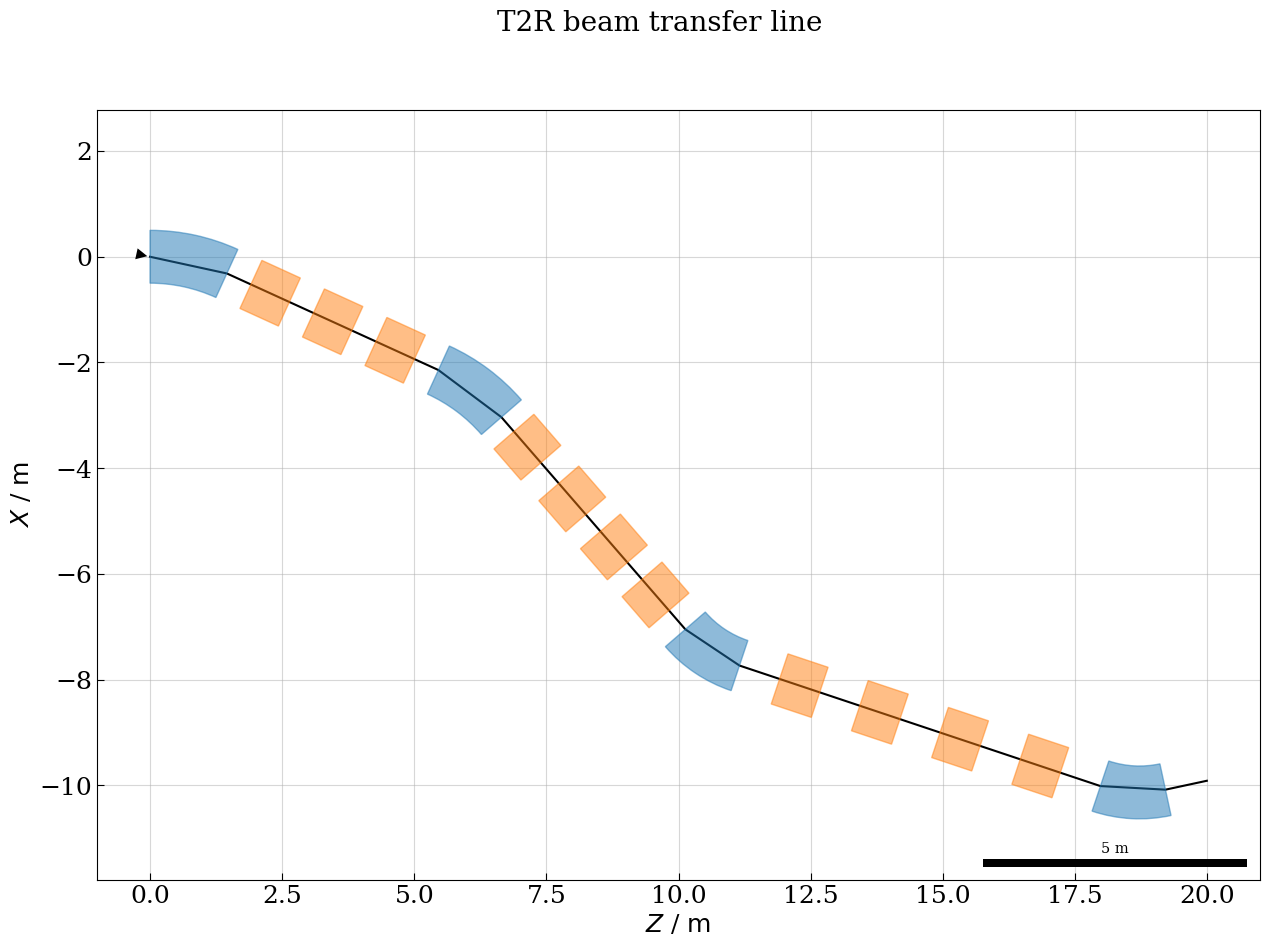

In [18]:
if True :
    import xplt
    plot = xplt.FloorPlot(t2rline.survey(), figsize=(15,10))
    plot.add_scale()
    plot.title('T2R beam transfer line')
    plot.ax.set(ylim=(-10, 1))
    
    _xval = [t2rline_df.iloc[0].Z, t2rline_df.iloc[-1].Z]
 
    # plot2 = xplt.KnlPlot(t2rline, figsize=(7, 3))
    # plot2.ax.set(ylim=(-1, 1));

In [19]:
# --- T2R segments
_segments = [group for _, group in t2rline_elements_df[t2rline_elements_df.element_type.isin(['Bend', 'Quadrupole'])].groupby("theta", sort=False)]
print(len(_segments))
t2r_segments = []
for seg in _segments:
    print(f' --- new segment: angle = {seg.iloc[0].theta:.6f} [rad]')
    print(f' \t elements = {seg.belement.values}')
    _slen = seg.iloc[-1].s_end - seg.iloc[0].s_start 
    print(f'\t  s-length = {_slen:.6f}')

4
 --- new segment: angle = 0.000000 [rad]
 	 elements = ['TLmb1']
	  s-length = 1.500000
 --- new segment: angle = -0.428280 [rad]
 	 elements = ['TLmq1' 'TLmq2' 'TLmq3' 'TLmb2']
	  s-length = 5.400000
 --- new segment: angle = -0.856560 [rad]
 	 elements = ['TLmq4' 'TLmq5' 'TLmq6' 'TLmq7' 'TLmb3']
	  s-length = 6.199397
 --- new segment: angle = -0.322250 [rad]
 	 elements = ['TLmq8' 'TLmq9' 'TLmq10' 'TLmq11' 'TLmb4']
	  s-length = 7.647573


## Match the injection geonetry

- track the pions in the cell arc to define the separation after the second quad 
- track the pions in the T2R line to get the direction vector at the end
- determine the septum strenth(angle) and locaiton to match the pointing to the LEMOND detector

In [20]:
# --- setup an arc_cell copy for the injection

inj_cell = nustorm_ring_segments['arc_cell'].copy()
inj_cell_tbl = inj_cell.get_table(attr=True)
display(inj_cell_tbl.show(cols=['name','s','s_start','s_center','s_end','length','k1l']))


name                        s       s_start      s_center         s_end        length ...
start_cell.A::0             0             0             0             0             0
QF.A::0                     0             0        0.0625         0.125         0.125
||drift_1::0            0.125         0.125         0.225         0.325           0.2
B::0                    0.325         0.325         0.675         1.025           0.7
||drift_2::0            1.025         1.025         1.125         1.225           0.2
QD.A::0                 1.225         1.225        1.2875          1.35         0.125
QD.A::1                  1.35          1.35        1.4125         1.475         0.125
||drift_3::0            1.475         1.475         2.025         2.575           1.1
QF.A::1                 2.575         2.575        2.6375           2.7         0.125
QF.A::2                   2.7           2.7        2.7625         2.825         0.125
||drift_3::1            2.825         2.825       

None

In [21]:
# --- add septum location in the middle between the QF/QD quads
s_mid = (inj_cell_tbl['s_end', 'QF.A::2'] + inj_cell_tbl['s_start', 'QD.A::2']) / 2
inj_cell._env.new('septum', xt.Marker)
inj_cell.insert([inj_cell._env.place('septum', at=s_mid)])

inj_cell_tbl = inj_cell.get_table(attr=True)
display(inj_cell_tbl.show(cols=['name','s','s_start','s_center','s_end','length','k1l']))


Slicing line:   0%|          | 0/18 [00:00<?, ?it/s]

name                        s       s_start      s_center         s_end        length ...
start_cell.A::0             0             0             0             0             0
QF.A::0                     0             0        0.0625         0.125         0.125
||drift_1::0            0.125         0.125         0.225         0.325           0.2
B::0                    0.325         0.325         0.675         1.025           0.7
||drift_2::0            1.025         1.025         1.125         1.225           0.2
QD.A::0                 1.225         1.225        1.2875          1.35         0.125
QD.A::1                  1.35          1.35        1.4125         1.475         0.125
||drift_3               1.475         1.475         2.025         2.575           1.1
QF.A::1                 2.575         2.575        2.6375           2.7         0.125
QF.A::2                   2.7           2.7        2.7625         2.825         0.125
||drift_4               2.825         2.825       

None

In [22]:
# --- setup tracking for the line
inj_cell.set_particle_ref('proton', p0c=0.6e9) # 600 MeV particles
_context = xo.ContextCpu()
inj_cell.build_tracker(_context)

particles = inj_cell.build_particles(
    x = [0.0, 0.0], px = [0.0, 0.0],
    y = [0.0, 0.0], py = [0.0, 0.0],
    delta=[0.0, (1.050-0.6)/0.6]
)

inj_cell.track(particles, turn_by_turn_monitor='ONE_TURN_EBE')

rec = inj_cell.record_last_track

print(len(rec.x[0,:]))


21


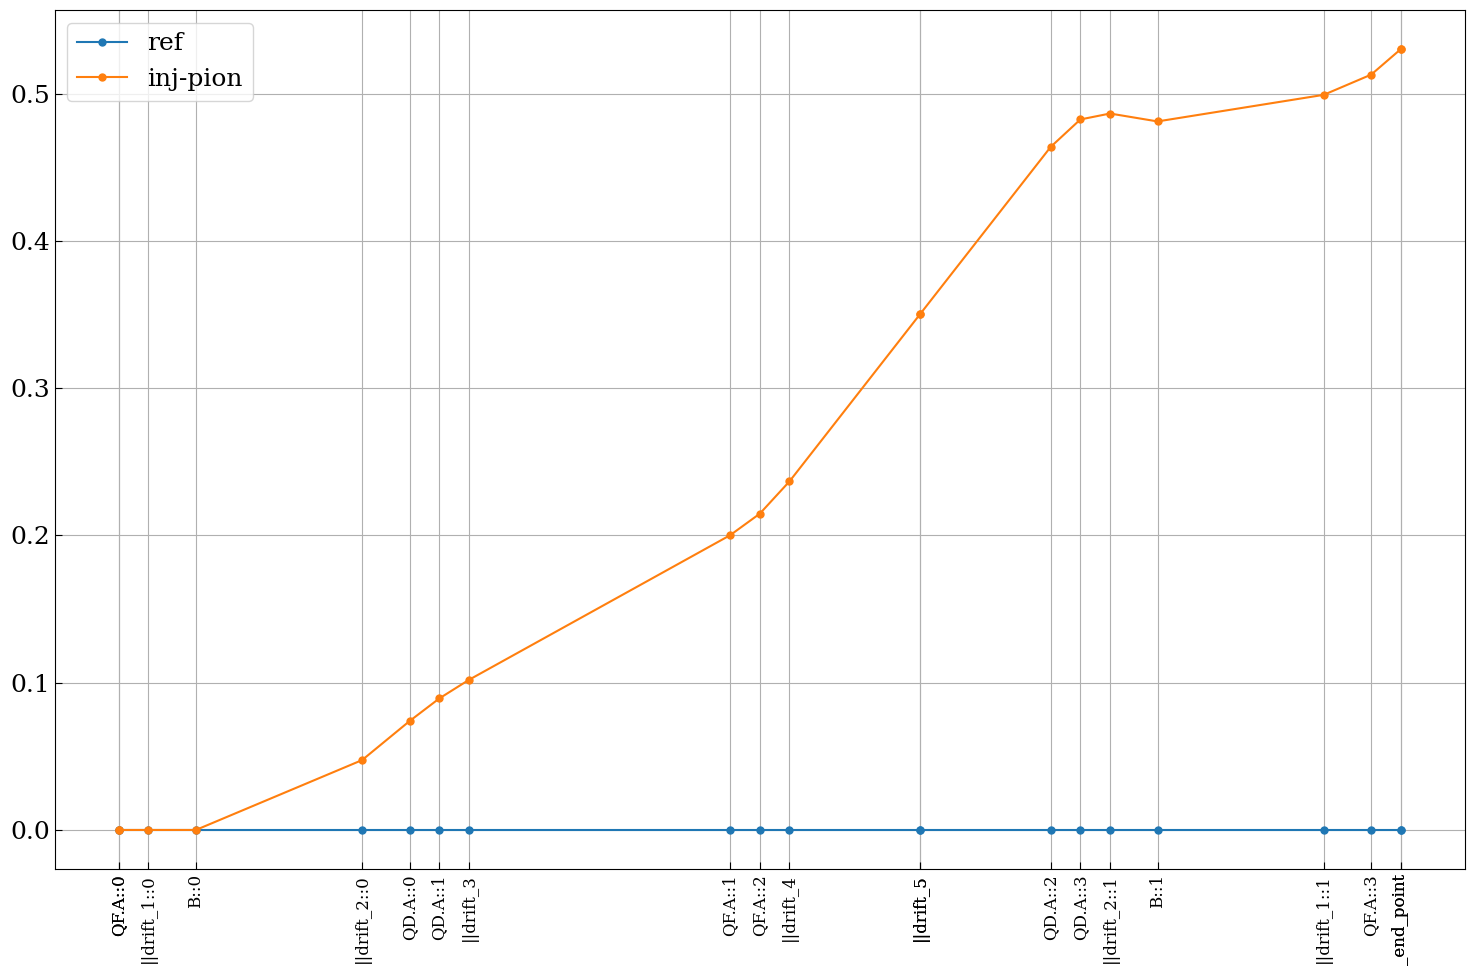

In [23]:
# tt = line.get_table()
plt.plot(inj_cell_tbl.s, rec.x[0, :], 'o-', ms=5, label='ref')
plt.plot(inj_cell_tbl.s, rec.x[1, :], 'o-', ms=5, label='inj-pion')

plt.xticks(inj_cell_tbl.s, inj_cell_tbl.name, rotation=90, fontsize=12)
plt.tight_layout()  # prevent label clipping
plt.legend()
plt.grid()

theta_ref             x            px      s         X  \
element         ip                                                           
start_cell.A::0 0         0.0  0.000000e+00  0.000000e+00  0.000  0.000000   
                1         0.0  0.000000e+00  0.000000e+00  0.000  0.000000   
QF.A::0         0         0.0  0.000000e+00  0.000000e+00  0.000  0.000000   
                1         0.0  0.000000e+00  0.000000e+00  0.000  0.000000   
||drift_1::0    0         0.0  0.000000e+00  0.000000e+00  0.125  0.000000   
                1         0.0  0.000000e+00  0.000000e+00  0.125  0.000000   
B::0            0         0.0  0.000000e+00  0.000000e+00  0.325  0.000000   
                1         0.0  0.000000e+00  0.000000e+00  0.325  0.000000   
||drift_2::0    0       -18.0  2.145739e-11  6.080177e-11  1.025 -0.109054   
                1       -18.0  4.744413e-02  2.317627e-01  1.025 -0.063932   
QD.A::0         0       -18.0  3.361774e-11  6.080177e-11  1.225 -0.170858   
                1       -18.0  7.393130e-02  2.317627e-01  1.225 -0.100545   
QD.A::1         0       -18.0  4.026128e-11  4.502355e-11  1.350 -0.209485   
                1       -18.0  8.928213e-02  1.969720e-01  1.350 -0.124573   
||drift_3       0       -18.0  4.477417e-11  2.686266e-11  1.475 -0.248112   
                1       -18.0  1.019279e-01  1.562134e-01  1.475 -0.151173   
QF.A::1         0       -18.0  7.432311e-11  2.686266e-11  2.575 -0.588031   
                1       -18.0  2.001192e-01  1.562134e-01  2.575 -0.397706   
QF.A::2         0       -18.0  7.993022e-11  6.329442e-11  2.700 -0.626658   
                1       -18.0  2.147427e-01  2.544027e-01  2.700 -0.422425   
||drift_4       0       -18.0  9.030366e-11  1.035005e-10  2.825 -0.665285   
                1       -18.0  2.366682e-01  3.612425e-01  2.825 -0.440200   
septum          0       -18.0  1.472289e-10  1.035005e-10  3.375 -0.835244   
                1       -18.0  3.502015e-01  3.612425e-01  3.375 -0.502183   
||drift_5       0       -18.0  1.472289e-10  1.035005e-10  3.375 -0.835244   
                1       -18.0  3.502015e-01  3.612425e-01  3.375 -0.502183   
QD.A::2         0       -18.0  2.041542e-10  1.035005e-10  3.925 -1.005204   
                1       -18.0  4.637349e-01  3.612425e-01  3.925 -0.564166   
QD.A::3         0       -18.0  2.115755e-10  1.471378e-11  4.050 -1.043831   
                1       -18.0  4.823824e-01  1.595669e-01  4.050 -0.585058   
||drift_2::1    0       -18.0  2.078001e-10 -7.485160e-11  4.175 -1.082458   
                1       -18.0  4.864149e-01 -4.694325e-02  4.175 -0.619850   
B::1            0       -18.0  1.928298e-10 -7.485160e-11  4.375 -1.144261   
                1       -18.0  4.810500e-01 -4.694325e-02  4.375 -0.686756   
||drift_1::1    0       -36.0  1.533110e-10 -3.712924e-11  5.075 -1.460749   
                1       -36.0  4.990987e-01  1.202073e-01  5.075 -1.056970   
QF.A::3         0       -36.0  1.458851e-10 -3.712924e-11  5.275 -1.578306   
                1       -36.0  5.128366e-01  1.202073e-01  5.275 -1.163413   
start_cell.A::1 0       -36.0  1.455476e-10  3.170172e-11  5.400 -1.651780   
                1       -36.0  5.301904e-01  3.670706e-01  5.400 -1.222847   
_end_point      0       -36.0  1.455476e-10  3.170172e-11  5.400 -1.651780   
                1       -36.0  5.301904e-01  3.670706e-01  5.400 -1.222847   

                           Z   angle_local  angle_total  angle_world  
element         ip                                                    
start_cell.A::0 0   0.000000  0.000000e+00     0.000000     0.000000  
                1   0.000000  0.000000e+00     0.000000     0.000000  
QF.A::0         0   0.000000  0.000000e+00     0.000000     0.000000  
                1   0.000000  0.000000e+00     0.000000     0.000000  
||drift_1::0    0   0.125000  0.000000e+00     0.000000     0.000000  
                1   0.125000  0.000000e+00     0.000000     0.000000  
B::0            0  

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


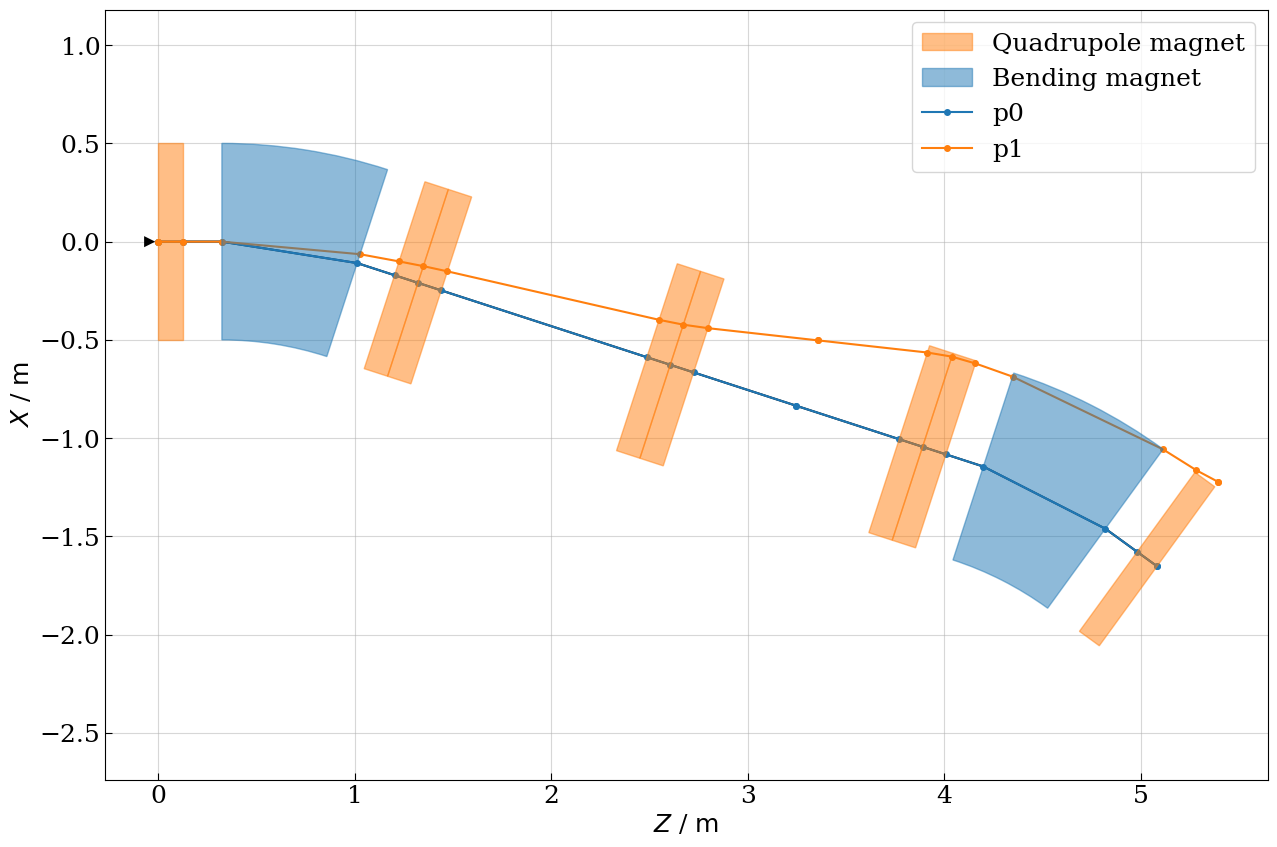

In [25]:
# --- plot tracks in world coordinates
survey = inj_cell.survey()

X_ref = np.array(survey.X)
Z_ref = np.array(survey.Z)
s_ref = np.array(survey.s)

theta = np.array(survey.theta)
n_elements = len(inj_cell.element_names)
n_particles = rec.x.shape[0]

X_tracks = []
Z_tracks = []
for ip in range(n_particles):
    x_local = rec.x[ip]
    x_local = rec.x[ip]
    X_tracks.append(X_ref + x_local * np.cos(theta))
    Z_tracks.append(Z_ref - x_local * np.sin(theta))

rows = []
for ii, name in enumerate(survey.name): # enumerate(inj_cell.element_names):
    for ip in range(n_particles):
        if ii < n_elements - 1:
            dX = X_tracks[ip][ii+1] - X_tracks[ip][ii]
            dZ = Z_tracks[ip][ii+1] - Z_tracks[ip][ii]
            angle_world = np.arctan2(dX, dZ) # np.degrees(np.arctan2(dX, dZ))
        else:
            angle_world = np.nan

        rows.append({
            'element'     : name,
            'ip'          : ip,
            'theta_ref'   : np.degrees(theta[ii]),      # [deg]
            'x'           : rec.x[ip, ii],
            'px'          : rec.px[ip, ii],
            's'           : s_ref[ii],
            'X'           : X_tracks[ip][ii],
            'Z'           : Z_tracks[ip][ii],
            'angle_local' : rec.px[ip, ii],             # [rad] np.degrees(rec.px[ip, ii]),
            'angle_total' : theta[ii] + rec.px[ip, ii], # [rad] np.degrees(theta[ii] + rec.px[ip, ii]),
            'angle_world' : angle_world,
        })

tracks_df = pd.DataFrame(rows).set_index(['element', 'ip'])
# tracks_df = tracks_df.sort_index()
display(tracks_df)

plot = xplt.FloorPlot(survey, figsize=(15, 10))
colors = plt.cm.tab10.colors
for ip in range(n_particles):
    plot.ax.plot(Z_tracks[ip], X_tracks[ip], 'o-', ms=4,
                 color=colors[ip % 10], label=f'p{ip}')
plot.ax.legend()


,X,Z,X_local,Z_local
element,,,,
start_cell.A::0,0.000000,0.000000,-1.286349e-01,3.391661
QF.A::0,0.000000,0.000000,-1.286349e-01,3.391661
||drift_1::0,0.000000,0.125000,-1.424310e-01,3.267425
B::0,0.000000,0.325000,-1.645048e-01,3.068647
||drift_2::0,-0.063932,1.028203,-1.785748e-01,2.362683
QD.A::0,-0.100545,1.226599,-1.640826e-01,2.161458
QD.A::1,-0.124573,1.350225,-1.538462e-01,2.035936
||drift_3,-0.151173,1.473015,-1.409607e-01,1.910960
QF.A::1,-0.397706,2.549520,-1.474620e-02,0.813823


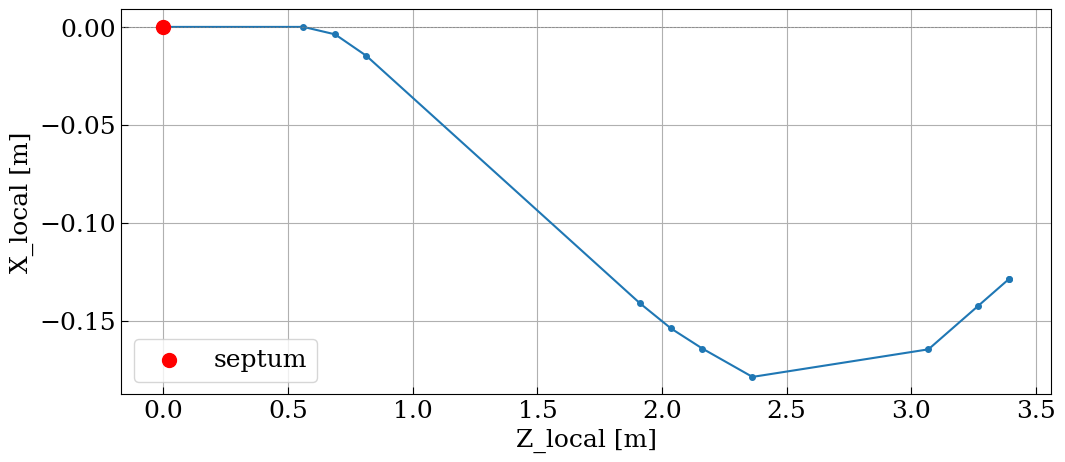

In [26]:
_dfy = tracks_df.xs(1, level='ip')
idx_septum = list(_dfy.index).index('septum')
_seg = _dfy.iloc[0:idx_septum + 1].copy()

# two reference points defining the horizontal direction
X_sep    = _seg.loc['septum', 'X']
Z_sep    = _seg.loc['septum', 'Z']
X_drift4 = _seg.loc['||drift_4', 'X']
Z_drift4 = _seg.loc['||drift_4', 'Z']

# angle of the septum -> drift4 segment in world frame
theta_ref = np.arctan2(X_drift4 - X_sep, Z_drift4 - Z_sep)

# translate so septum is at origin, then rotate so septum->drift4 is horizontal
dX = _seg['X'] - X_sep
dZ = _seg['Z'] - Z_sep


# rotate: septum->drift4 becomes horizontal (along Z_local)
_seg['X_local'] = dX * np.cos(theta_ref) - dZ * np.sin(theta_ref)
_seg['Z_local'] = dX * np.sin(theta_ref) + dZ * np.cos(theta_ref)

display(_seg[['X', 'Z', 'X_local', 'Z_local']])

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(_seg['Z_local'].values[::-1], _seg['X_local'].values[::-1], 'o-', ms=4)
ax.axhline(0, color='gray', lw=0.5, ls='--')   # horizontal reference
ax.scatter([0], [0], color='red', s=100, zorder=5, label='septum')
ax.set_xlabel('Z_local [m]')
ax.set_ylabel('X_local [m]')
ax.legend()
ax.grid()



In [33]:
inj_cell_tbl.show()
inj_seg = inj_cell.select(start='start_cell.A::0', end='septum')
# inj_line.get_table()

print(f'\n\n --- Injection segment:')
inj_seg = -inj_seg
inj_seg_tbl = inj_seg.get_table(attr=True)
cols=['s', 'element_type', 'k0l', 'k1l', 'isthick', 'shift_x']
inj_seg_tbl.show(cols=cols)

name                        s element_type isthick isreplica parent_name parent_type prototype ...
start_cell.A::0             0 Marker         False     False None        None        None     
QF.A::0                     0 Quadrupole      True     False None        None        Q        
||drift_1::0            0.125 Drift           True     False None        None        None     
B::0                    0.325 Bend            True     False None        None        None     
||drift_2::0            1.025 Drift           True     False None        None        None     
QD.A::0                 1.225 Quadrupole      True     False None        None        Q        
QD.A::1                  1.35 Quadrupole      True     False None        None        Q        
||drift_3               1.475 Drift           True     False None        None        None     
QF.A::1                 2.575 Quadrupole      True     False None        None        Q        
QF.A::2                   2.7 Quadrupole      

In [42]:
# --- apply the shift based on the track_df information. 
# pay attention to the element names as they change dynamically
print(f''' shifts to apply: 
            QF.A::0 = {tracks_df.loc[("QF.A::2", 1)].x:.5f}
            QF.A::1 = {tracks_df.loc[("QF.A::1", 1)].x:.5f}
            QD.A::0 = {tracks_df.loc[("QD.A::1", 1)].x:.5f}
            QD.A::1 = {tracks_df.loc[("QD.A::0", 1)].x:.5f}
        '''
      )
# print(inj_seg.element_dict['QF.A::0'])
print(inj_seg.element_dict)
print(inj_seg_tbl.rows['QF.A::0'])

 shifts to apply: 
            QF.A::0 = 0.21474
            QF.A::1 = 0.20012
            QD.A::0 = 0.08928
            QD.A::1 = 0.07393
        
{'start_cell.A': Marker(), 'QF.A': Quadrupole(k1=-3.8, k1s=0, length=0.125, num_multipole_kicks=np.int64(0), order=np.int64(5), inv_factorial_order=0.00833, knl=[0., 0., 0., 0., 0., 0.], ksl=[0., 0., 0., 0., 0., 0.], knl_rel=[0.], ksl_rel=[0.], main_is_skew=False, edge_entry_active=np.uint64(0), edge_exit_active=np.uint64(0), model='adaptive', integrator='adaptive', radiation_flag=np.int64(0), delta_taper=0, shift_x=0, shift_y=0, shift_s=0, rot_s_rad=0, rot_x_rad=0, rot_y_rad=0, rot_s_rad_no_frame=0, rot_shift_anchor=0), 'QD.A': Quadrupole(k1=3.4, k1s=0, length=0.125, num_multipole_kicks=np.int64(0), order=np.int64(5), inv_factorial_order=0.00833, knl=[0., 0., 0., 0., 0., 0.], ksl=[0., 0., 0., 0., 0., 0.], knl_rel=[0.], ksl_rel=[0.], main_is_skew=False, edge_entry_active=np.uint64(0), edge_exit_active=np.uint64(0), model='adaptive', integra

### Append elements to T2R line for the injection

In [61]:
# --- combine elements to the full injection line
t2rinj_env = xt.Environment()

# copy element to the same environment
for src_line in [t2rline, inj_seg]:
    t2rinj_env._element_dict.update(src_line.env._element_dict)

# compose the full line
t2rinj_line = t2rinj_env.new_line(components=[
    t2rinj_env.new('dr0', xt.Drift, length=2.0),
    t2rline,
    t2rinj_env.new('dr1', xt.Drift, length=0.10), # this can be part of the layout matching
    inj_seg
])

# -- replace septum with a bend
_tt = t2rinj_line.get_table()
i = list(_tt.name).index('septum')
t2rinj_line.remove('septum')

septum_angle_rad = 300.0e-3   # septum angle - part of the layout matching
septbend = xt.Bend(angle=septum_angle_rad, length=0.4)
t2rinj_line.insert('septbend', septbend, at= _tt.s[i] )

if True : 
    t2rinj_line['QF.A::0'].shift_x = tracks_df.loc[("QF.A::2", 1)].x
    t2rinj_line['QF.A::1'].shift_x = tracks_df.loc[("QF.A::1", 1)].x
    
    t2rinj_line['QD.A::0'].shift_x = tracks_df.loc[("QD.A::1", 1)].x
    t2rinj_line['QD.A::1'].shift_x = tracks_df.loc[("QD.A::0", 1)].x


tt = t2rinj_line.get_table()
print(tt.show(rows=None))
t2rinj_survey = t2rinj_line.survey()

Slicing line:   0%|          | 0/45 [00:00<?, ?it/s]

name                            s element_type isthick isreplica parent_name parent_type prototype ...
dr0                             0 Drift           True     False None        None        None     
mbtl0.0                         2 Bend            True     False None        None        None     
drift_1                       3.5 Drift           True     False None        None        None     
mq_t2r.0                        4 Quadrupole      True     False None        None        None     
drift_2                       4.8 Drift           True     False None        None        None     
mq_t2r.1                      5.3 Quadrupole      True     False None        None        None     
drift_3                       6.1 Drift           True     False None        None        None     
mq_t2r.2                      6.6 Quadrupole      True     False None        None        None     
drift_4                       7.4 Drift           True     False None        None        None     
mbtl0.

In [76]:
_dfy = t2rinj_survey.to_pandas()
_dfy.iloc[-1].T
print(f''' nuSTORM ring injection point:
      (X, Z) : {_dfy.iloc[-1].X:.5f}, {_dfy.iloc[-1].Z:.5f} [m]
      angle  : {_dfy.iloc[-1].theta:.5f} [rad]
      
      angle to ND : {np.atan2(_dfy.iloc[-1].X, 350 - _dfy.iloc[-1].Z):.5f} [rad]
      '''
      )

 nuSTORM ring injection point:
      (X, Z) : -10.39631, 25.41327 [m]
      angle  : -0.40210 [rad]
      
      angle to ND : -0.03202 [rad]
      


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


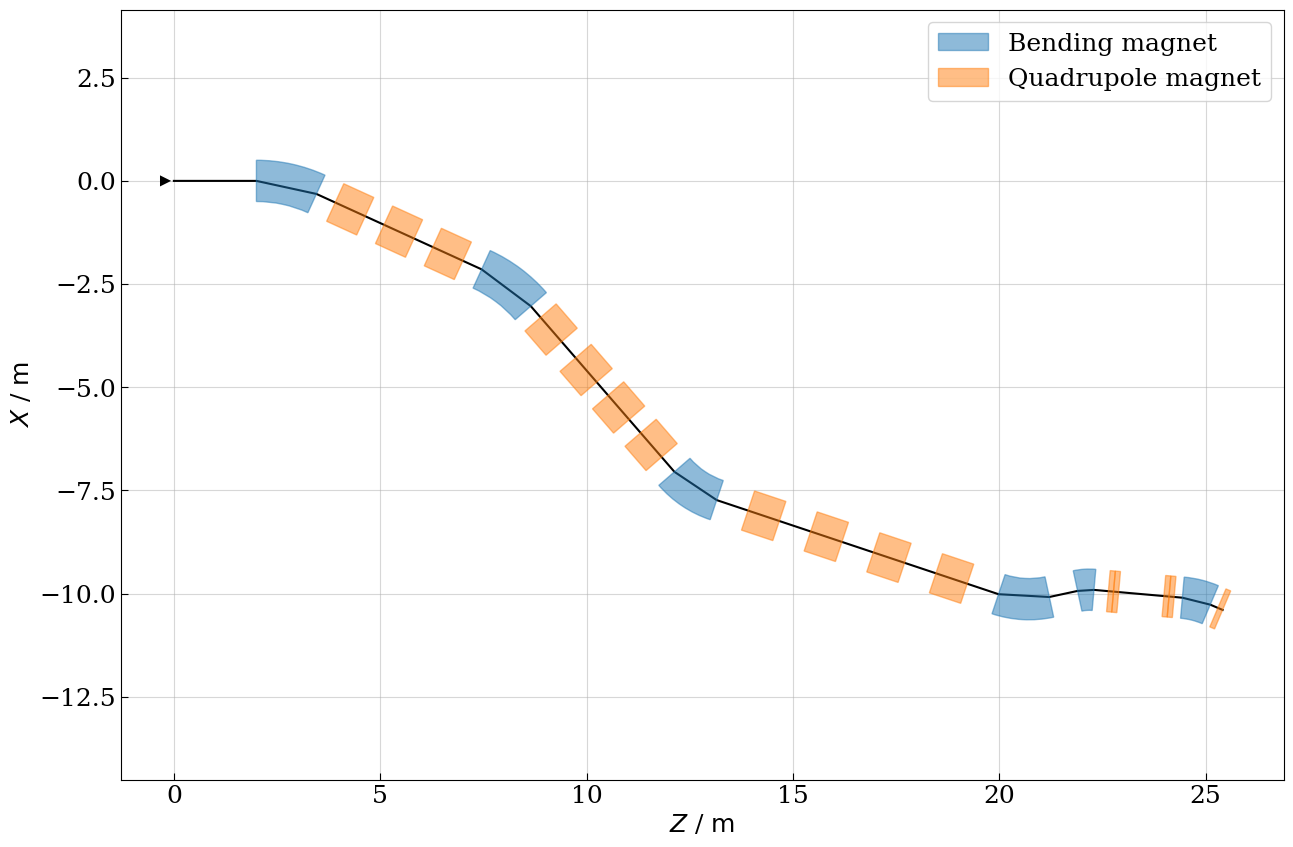

In [68]:
plot = xplt.FloorPlot(t2rinj_survey, figsize=(15, 10))
plot.ax.legend()


## Build FLUKA Geometry

Model parking area
x = -500 +500     Dx = 10 m
z = -20000 -5000 Dz = 150 m

Injection point to LEnuSTORM ring
x = -10 m from target
z =  15 m from target
angle = to point to a ND module at 250m from the target.

**Note** : for FLUKA the units are converted to cm 

In [ ]:
# -- calculate overall angle of LEnuSTORM ring
# Note: 
# - the points are always as {x,z} or {x,y,z} coordinates 
# - units are [m, rad], other units are defined in the name of the variable

t2r_start   = config.t2r_start
t2r_end     = t2r_start + t2rline_df[['X', 'Z']].iloc[-1].to_numpy()
t2r_angle   = np.arcsin(t2rline_df.iloc[-1].X/t2rline_df.iloc[-1].Z)
t2r_length  = np.linalg.norm(t2rline_df.iloc[-1][['X','Z']].to_numpy())

config.update({'t2r_end'        : t2r_end,
               't2r_angle'      : t2r_angle,
               't2r_angle_deg'  : t2r_angle * 180/np.pi,
               't2r_length'     : t2r_length,
               })

lblnd_point = [0, config.trg_to_lblnd]

injection_point         = np.add(t2r_start, config.t2rstart_to_inj)
nsring_angle, nsring_c  =  bsim.line_from_points(injection_point[::-1], lblnd_point[::-1])
nsring_angle_deg        = nsring_angle*180/np.pi
nsring_width            = nustormring_df.X.max() - nustormring_df.X.min() + 2*config.magnet_width
nsring_length           = nustormring_df.Z.max() - nustormring_df.Z.min() - 2*config.magnet_width

config.update({
    'nsring_inj'        : injection_point,
    'nsring_angle'      : nsring_angle,
    'nsring_angle_deg'  : nsring_angle_deg,
    'nsring_width'      : nsring_width,
    'nsring_length'     : nsring_length,
    
})

nsdist_to_dtnl = bsim.distance_point_to_line([nsring_angle, nsring_c], [config.l_decay_tunnel, -config.w_decay_tunnel[0]/2])
config.update({'nsdist_to_dtnl' : nsdist_to_dtnl})

print(f' === Parameters for the T2R line and LEnuSTORM ring ====')
print(f' -  target to ND distance ...................[m] {config.trg_to_lblnd}')
print(f' -  T2R beam transfer line:')
print(f'              start .........................[m] x={t2r_start[0]} z={t2r_start[1]}')
print(f'              end ...........................[m] x={t2r_end[0]} z={t2r_end[1]}')
print(f'              angle .........................{t2r_angle:.5f} [rad], {t2r_angle*180/np.pi:.2f} [deg]')

print(f' -  LEnuSTORM ring:')
print(f'              injection point to target .....[m] x={injection_point[0]} z={injection_point[1]}')
print(f'              angle ......................... {nsring_angle:.5f} [rad] {nsring_angle_deg:.3f} [deg]')
print(f'              tunnel width ..................[m] x={nsring_width:.5f} ')
print(f'              tunnel length .................[m] x={nsring_length:5f} ')

print(f' - Distance to edge of the decay tunnel .....[m] {nsdist_to_dtnl:.5f} ')


In [ ]:
# --- Update the T2R and nuSTORM dataframes with the final position and rotation

t2rline_elements_df[['Xp', 'Zp']] = (t2rline_elements_df[['X', 'Z']] + t2r_start)
t2rline_elements_df[['Xp_cm', 'Zp_cm']] = (t2rline_elements_df[['Xp', 'Zp']])*100


# --- Rotation matrix ---
R = np.array([[np.cos(-nsring_angle), -np.sin(-nsring_angle)],
              [np.sin(-nsring_angle),  np.cos(-nsring_angle)]])

rotated = nustormring_elements_df[['X', 'Z']].to_numpy() @ R.T  # matrix multiply
nustormring_elements_df['Xp'] = rotated[:,0] + injection_point[0]
nustormring_elements_df['Zp'] = rotated[:,1] + injection_point[1]
nustormring_elements_df[['Xp_cm', 'Zp_cm']] = (nustormring_elements_df[['Xp', 'Zp']])*100



In [ ]:
fig,ax = plt.subplots(figsize=(15,10))

# ax.plot(t2rline_elements_df.Z+t2r_start[1], t2rline_elements_df.X+t2r_start[0], label='T2R line')
ax.plot(t2rline_elements_df.Zp, t2rline_elements_df.Xp, label='T2R line')

_twidth = config.w_tline_tunnel
_bottom_left_corner = (-_twidth/2 * np.cos(t2r_angle), _twidth/2 * np.sin(t2r_angle))
_width = _twidth
_length = np.linalg.norm(t2rline_df.iloc[-1][['X','Z']].to_numpy())

rect = patches.Rectangle(_bottom_left_corner, _length, _width,
                         angle =t2r_angle*180/np.pi,
                         facecolor='lightblue',
                         fill=False, edgecolor='blue', linestyle='--', linewidth=0.6)
ax.add_patch(rect)

# ax.plot(_dfy.Zrot, _dfy.Xrot, label='nuSTORM ring')
ax.plot(nustormring_elements_df.Zp, nustormring_elements_df.Xp, label='nuSTORM ring')

_bottom_left_corner = (nustormring_elements_df.Zp.min()-3, nustormring_elements_df.Xp.min()-3)
_width = nustormring_elements_df.X.max() - nustormring_elements_df.X.min()+2*3
_length = nustormring_elements_df.Z.max() - nustormring_elements_df.Z.min() + 2*3

rect = patches.Rectangle(_bottom_left_corner, _length, _width,
                         angle = nsring_angle*180/np.pi, 
                         facecolor='lightblue',
                         fill=False, edgecolor='blue', linestyle='--', linewidth=0.6)
ax.add_patch(rect)

lblline = list(zip([0,0],lblnd_point))
ax.plot(lblline[1], lblline[0], '--', label='LBL line')
ax.plot(config.trg_to_lblnd, 0, '*', label='ND')
ax.legend(ncols=2)
ax.set_ylim(-40, 40)
ax.set_aspect('equal', adjustable='box')
ax.set_title('ESSnuSB+ LEnuSTORM Layout')



### Create magnet models

In [ ]:
if True : 
    k0 = 0.428
    slength = 2.21
    angle = 0.428*slength
    print(f'{angle=} {angle*180/np.pi=}')
    rho = 1/k0
    arc = 2*rho*np.sin(angle/2)
    print(f'{k0=}, {angle=}, {rho=}, {arc=}')
    zlength = rho*np.sin(angle)
    b0 = angle*1000*0.7/299.79/slength
    print(f' {zlength=}, {b0=}')


In [ ]:
def create_quad_model(name, length, verbose=False):
    ''' Create the model of the quads'''
    aperture = 20
    width = 3.9*aperture
    height = width
    name = name.lower()
    bodies = f'''
RPP     {name}vol {-width/2-0.1} {width/2+0.1} {-width/2-0.1} {width/2+0.1} -0.1 {length+0.1}
RPP     {name}fe {-width/2} {width/2} {-width/2} {width/2} 0 {length}
RCC     {name}vac 0.0 0.0 -0.1 0.0 0.0 {length+0.1} {aperture/2}'''

    regions = f'''
{name.upper()}Env 5
    +{name}vol -{name}fe -{name}vac
{name.upper()}Fe 5
    +{name}fe -{name}vac
{name.upper()}Vac 5
    +{name}vac '''
    
    replica = f'''
RPP     replica {-width/2-0.1} {width/2+0.1} {-width/2-0.1} {width/2+0.1} -0.1 {length+0.1}'''

#    lattice = f'''
#LATTICE, rpregion, , , {name.upper()}Env, , ,transform'''
    lattice = f'''
LATTICE, rpregion, , , latregion, , ,transform'''

    if verbose:
        print(f'''--- QUAD model :
              name ......... {name}
              length ....... {length}
              width ........ {width}
              height ....... {height}
              aperture ..... {aperture}
              ''')


    return bodies, regions, replica, lattice

def create_bend_model(name, slength, k0, verbose=False):
    ''' Create the model of the bends'''
    beam_size = 20
    angle = k0*(slength/100)
    rho = 1/k0*100
    arc = 2*rho*np.sin(angle/2)
    defl = arc*np.sin(angle/2)
    length = rho * np.sin(angle)
    width = 2*(defl + beam_size)*1.2 + 2*30  # here the beam enters the center of the dipole
    height = beam_size + 2*30
    aperx = 2*(defl + beam_size)*1.2
    apery = 1.2 * beam_size
    name = name.lower()
    if verbose:
        print(f'''--- BEND model :
              name ......... {name}
              slength ...... {slength}
              k0 ........... {k0}
              angle ........ {angle}
              rho .......... {rho}
              arc .......... {arc}
              deflection ... {defl}
              length ....... {length}
              width ........ {width}
              height ....... {height}
              aperx ........ {aperx}
              apery ........ {apery}
              ''')
    bodies = f'''
RPP     {name}vol {-width/2-0.1} {width/2+0.1} {-height/2-0.1} {height/2+0.1} -0.1 {length+0.1}
RPP     {name}fe {-width/2} {width/2} {-height/2} {height/2} 0 {length}
RPP     {name}vac {-aperx/2} {aperx/2} {-apery/2} {apery/2} -0.1 {length+0.1}''' 

    regions = f'''
{name.upper()}Env 5
    +{name}vol -{name}fe -{name}vac
{name.upper()}Fe 5
    +{name}fe -{name}vac
{name.upper()}Vac 5
    +{name}vac'''
    
    replica = f'''
RPP     replica {-width/2-0.1} {width/2+0.1} {-width/2-0.1} {width/2+0.1} -0.1 {length+0.1}''' 

#    lattice = f'''
#LATTICE, rpregion, , , {name.upper()}Env, , ,transform'''
    lattice = f'''
LATTICE, rpregion, , , latregion, , ,transform'''


    return bodies, regions, replica, lattice

In [ ]:
_aux = t2rline_elements_df.dropna(subset='model')
models_dict = {}
models_dict = _aux.set_index("model").apply(lambda r: 
                {'length' : round(r["length"]*100, 2), 
                 'type'   : r["element_type"], 
                 'kvalue' : r["kvalue"]}, axis=1).to_dict()

_aux = nustormring_elements_df.dropna(subset='model')
models_dict.update(_aux.set_index("model").apply(lambda r: 
                {'length' : round(r["length"]*100, 2), 
                 'type'   : r["element_type"], 
                 'kvalue' : r["kvalue"]}, axis=1).to_dict())

models_dict

In [ ]:
mparking = np.array(config.mparking_start)*100
mbodies_cards = []
mregions_cards = []

for mid, mparams in models_dict.items():
    print(f'{mid=}, {mparams=}')
    length, mtype, kvalue = mparams.values()
    
    if mtype == 'Quadrupole':
        bodies, regions, replica, lattice = create_quad_model(mid, length, False)
    elif mtype == 'Bend' :
        bodies, regions, replica, lattice = create_bend_model(mid, length, abs(kvalue), False)
    else:
        continue
    _rotdefi = ''
    bodies = f'$start_translat {mparking[0]} {mparking[1]} {mparking[2]}' + bodies + '\n$end_translat'
    models_dict[mid]['bodies'] = bodies
    mbodies_cards.append(bodies)

    replica = f'$start_translat {mparking[0]} {mparking[1]} {mparking[2]}' + replica + '\n$end_translat'
    models_dict[mid]['replicas'] = replica

    mregions_cards.append(regions)

    _thismodel = {'name': str(mid),
                  'bodies' : bodies,
                  'regions' : regions,
                  'replicas' : replica,
                  'lattice' : lattice,
                  'parking' : mparking.copy(),
                  }
    models_dict[mid].update(_thismodel) 
    
    mparking[2] += -300
# print(f' --- mparking_end = {mparking}')
config.update({'mparking_end': list(mparking/100)})
# print(f' ---- Model Bodies :')
# print(mbodies_cards)

# --- envelop body for the magnet model parking area

mpark_size = (config.mparking_start[2]+3) - config.mparking_end[2]
mbodies_cards.append(f'''
RCC mparki {mparking[0]} {mparking[1]} {mparking[2]} 0 0 {mpark_size*100} {config.mparking_radious*100}
RCC mparko {mparking[0]} {mparking[1]} {mparking[2]-100} 0 0 {mpark_size*100+100} {config.mparking_radious*100+100}
                     ''')
print(f' ---- Model Regions')
mregions_cards.append(f'''
MODELS 5
    +mparko -mparki
MODAIR 5
    +mparki -{" -".join([ s.lower()+"vol" for s in models_dict.keys()])}   
                      ''')
# print(mregions_cards)
print(f' --- Magnet Models dict : ')
pprint.pprint(models_dict) 

In [ ]:
def generate_inp_file(fname, title, cards, verbose=True):
    with open(fname, 'w', newline='\n') as f:
        f.write(f'''*\n*---- {title}  ----\n*\n''')
        for line in cards.split('\n'):
            f.write(line.replace('\r\n', '\n').replace('\r','') + '\n')
    if verbose : 
        print(f' --- created file {fname} with {len(cards.split("\n"))} lines')
    return

In [ ]:
generate_inp_file('magnet_models_bodies.inp', 'Magnet models bodies', '\n'.join(mbodies_cards))
generate_inp_file('magnet_models_regions.inp', 'Magnet models regions', '\n'.join(mregions_cards))

### Create T2R line elements

In [ ]:

t2r_replica_cards = ''
t2r_regions_cards = ' '
t2r_rotdefi_cards = ''
t2r_lattice_cards = ''
t2r_lattice_regions = ''

_x0cm, _z0cm = np.array(config.t2r_start)*100

for el in t2rline_elements_df.itertuples():
    print(el.name, el.belement, el.model)
    if el.model not in models_dict.keys():
        print (f' ---- {el.name=} cannot find model')
        continue
        
    model = models_dict[el.model]
    parking = model['parking']
    replica = model['replicas'].replace('replica', str(el.belement.lower()))
    # print(model, parking, replica)
    
    xc = _x0cm + el.X_cm
    yc = el.Y_cm
    zc = _z0cm + el.Z_cm
    angle = el.theta_deg

    _thisrotdefi = f'''
* - ROTDEFI for element {el.belement} at s={el.s_center}
ROT-DEFI  , 0, , ,{-xc}, {-yc}, {-zc}, t2rtr{el.Index}
ROT-DEFI  , 200, , {angle:.6g}, , , , t2rtr{el.Index} 
ROT-DEFI  , 300, , 0, {parking[0]}, {parking[1]}, {parking[2]}, t2rtr{el.Index} '''

    _thisreplica = f'''
$start_transform -t2rtr{el.Index}
{replica}
$end_transform'''

    t2r_lattice_regions += f' -{el.belement.lower()}'
    
    _thisregion = f'''
{el.belement.upper():8.8} 5
    +{el.belement.lower()}'''

    _thislattice = model['lattice'].replace('transform', f't2rtr{el.Index}').replace('rpregion',el.belement.upper()).replace('latregion',el.belement.upper())
       
    # print(_thisregion)
    # print(_thisrotdefi)
    # print(_thisreplica) 
    # print(_thislattice)
       
    t2r_replica_cards += _thisreplica
    t2r_rotdefi_cards += _thisrotdefi
    t2r_regions_cards += _thisregion
    t2r_lattice_cards += _thislattice

In [ ]:
generate_inp_file('t2rline_elements_rotdefi.inp', 'T2R line element ROT-DEFI', t2r_rotdefi_cards)
generate_inp_file('t2rline_elements_replicas.inp', 'T2R line element replicas', t2r_replica_cards)
generate_inp_file('t2rline_elements_regions.inp', 'T2R line element regions', t2r_regions_cards)
generate_inp_file('t2rline_elements_rattice.inp', 'T2R line element rattice', t2r_lattice_cards)


### Create LEnuSTORM beam elements

In [ ]:
# --- rename the bends as MBxx without dot

nustormring_elements_df['belement'] = nustormring_elements_df['belement'].apply(lambda x: x.replace('B.','MB')).values

In [ ]:
# -- sanity check if any name >8 characters that FLUKA needs
_dfy = nustormring_elements_df.copy()
_dfy['belement_nlen'] = _dfy['belement'].astype(str).apply(len)
mask = (
    (_dfy["element_type"] != "Drift") &
    (
        (_dfy["belement_nlen"] > 8) |
        (_dfy["belement"].astype(str).str.contains(r"\."))
    )
)
_dfy[mask][['element_type', 'name','belement', 'model']]

In [ ]:
if False:
    
    # --- the half length elements
    _cols2use = ['s_fr','element_type','name_fr','name_srv','el_name','model_id', 'model_name']
    lenustorm_df[lenustorm_df['Consecutive_Count'] != 1][frcols2use]
    
    # --- the full length or first elements

    lenustorm_magnetic_elements = lenustorm_df[(lenustorm_df.Consecutive_Count == 1) & (lenustorm_df.element_type != 'Drift')]
    lenustorm_magnetic_elements[frcols2use].tail()

In [ ]:
ns_replica_cards = ''
ns_regions_cards = ' '
ns_rotdefi_cards = ''
ns_lattice_cards = ''

ns_lattice_regions = ''


icount = 0
for el in nustormring_elements_df[nustormring_elements_df.element_type != 'Marker'].itertuples():
    if el.model not in models_dict.keys():
        print (f' --- {el.name=} : cannot find a model')
        continue
    model = models_dict[el.model]
    parking = model['parking']
    replica = model['replicas'].replace('replica', str(el.belement.lower()))
    print(f'{el.belement=}, {model=}, {parking=}, {replica=}')
    
    angle = -config.nsring_angle_deg - el.theta_deg + el.angle*180/np.pi/2
    if angle > 180 :
        # print(f' --- frtr{el.Index} ; element:{el.el_name} - {el.name_fr} {angle=:.5f} --> {360-angle:.5f} ({lenustorm_angle_deg=:.5f} {el.theta_deg:.5f} {el.angle*180/np.pi/2=:.5f})')
        angle = 360 - angle
    else:
        angle = -angle
        
    _thisrotdefi = f'''
*! - ROTDEFI for element {el.belement} at s={el.s_center}
ROT-DEFI  , 0, , ,{-el.Xp_cm:.5f}, ,{-el.Zp_cm:.5f}, nstr{el.Index}
ROT-DEFI  , 200, , {angle:.6g}, , , , nstr{el.Index} 
ROT-DEFI  , 300, , 0, {parking[0]}, {parking[1]}, {parking[2]}, nstr{el.Index} '''

    _thisreplica = f'''
$start_transform -nstr{el.Index}
{replica}
$end_transform'''
    
    _thisregion = f'''
{el.belement.upper():8.8} 5
    +{el.belement.lower()}'''

    _thislattice = model['lattice'].replace('transform', f'nstr{el.Index}').replace('rpregion',el.belement.upper()).replace('latregion', el.belement.upper())
    
    # print(_thisregion)
    # print(_thisrotdefi)
    # print(_thisreplica) 
    # print(_thislattice)
       
    ns_replica_cards += _thisreplica
    ns_rotdefi_cards += _thisrotdefi
    ns_regions_cards += _thisregion
    ns_lattice_cards += _thislattice
    
    ns_lattice_regions += f' -{el.belement.lower()}'
    if icount % 10 == 0 :
        ns_lattice_regions += '\n'

In [ ]:
generate_inp_file('lenustorm_elements_rotdefi.inp', 'LEnuSTORM element ROT-DEFI', ns_rotdefi_cards)
generate_inp_file('lenustorm_elements_replicas.inp', 'LEnuSTORM element replicas', ns_replica_cards)
generate_inp_file('lenustorm_elements_regions.inp', 'LEnuSTORM element regions', ns_regions_cards)
generate_inp_file('lenustorm_elements_lattice.inp', 'LEnuSTORM element lattice', ns_lattice_cards)


### Create target and Horn Assembly


In [ ]:
def create_target_and_horn(config=config):
    _bodies = ''
    _regions = ''

    _bodies += f'''
RPP thbox     {getcoord(config.thbox_x, 0)} {getcoord(config.thbox_y, 0)} {getcoord(config.thbox_z, 0)}
RCC target  0 0 0 0 0 {config.target_len*100} {config.target_radious*100}
    '''
    _regions += f'''
THBOX  5 
    +thbox -target
TARGET 5
    +target
    '''
    return _bodies, _regions

In [ ]:
th_bodies_cards, th_regions_cards = create_target_and_horn(config)

generate_inp_file('thbox_bodies.inp', 'Target & Horn Assembly', th_bodies_cards)
generate_inp_file('thbox_regions.inp', 'Target & Horn Assembly', th_regions_cards)


### Create global volumes 

- overall world and void regions
- target cavern
- tunnels for T2R and nuSTORM ring

In [ ]:
if False : 
    bsim_parameters
    print(lenustorm_df.Z.min(), tt_inj_point[1], bsim_parameters["w_ring_tunnel"])
    print(tt_inj_point[1]+lenustorm_df.Z.min()-bsim_parameters["w_ring_tunnel"]/2)

    print(tt_length)


    print(bsim_parameters["w_ring_tunnel"]*100, tt_inj_point[1]*100,  lenustorm_df.Z.min()*100)
    print(-bsim_parameters["w_ring_tunnel"]*100 + tt_inj_point[1]*100 + lenustorm_df.Z.min()*100)
    bsim_parameters
    pc_primary = np.sqrt(2.5*(2.5+2*0.9382))
    primary_d1_angle = tt_bend_angle*0.7/pc_primary
    print(f' --- primary beam momentum ... {pc_primary:.5g} [GeV]')
    print(f' --- angle in Bend1 .......... {primary_d1_angle:.5g} [deg]')
    bsim_parameters
    bsim_parameters


In [ ]:
getcoord(config.w_target_cavern, config.d_shield)

In [ ]:
glob_bodies = ''
glob_regions = ''
glob_rotdefi = ''

# --- Target Cavern and Decay pipea

tcc_xo = getcoord(config.w_target_cavern, config.d_shield)
tcc_yo = getcoord(config.h_target_cavern, config.d_shield)
tcc_zo = getcoord(config.z_target_cavern, 0)
tcc_xi = getcoord(config.w_target_cavern, 0)
tcc_yi = getcoord(config.h_target_cavern, 0)
tcc_zi = getcoord(config.z_target_cavern, 0)

tdec_xo = getcoord(config.w_decay_tunnel, config.d_shield)
tdec_yo = getcoord(config.h_decay_tunnel, config.d_shield)
tdec_zo = getcoord([config.z_target_cavern[1]-1, config.z_target_cavern[1]+config.l_decay_tunnel+1+config.d_shield], 0)
tdec_xi = getcoord(config.w_decay_tunnel, 0)
tdec_yi = getcoord(config.h_decay_tunnel, 0)
tdec_zi = getcoord([config.z_target_cavern[1]-1, config.z_target_cavern[1]+config.l_decay_tunnel+1], 0)

glob_bodies += f'''
SPH blkbody    0 0 0 100000
SPH void       0 0 0 90000
*
* --- target cavern
RPP tcco     {tcc_xo} {tcc_yo} {tcc_zo}
RPP tcci     {tcc_xi} {tcc_yi} {tcc_zi}
*
* --- decay tunnel
RPP tdeco     {tdec_xo} {tdec_yo} {tdec_zo}
RPP tdeci     {tdec_xi} {tdec_yi} {tdec_zi}
'''

# --- T2R tunnel

glob_rotdefi += f'''
ROT-DEFI , 200, {config.t2r_angle:.6g}, , , , t2rtun
ROT-DEFI , 300, 0, 0, 0, {t2r_start*100}, t2rtun
'''
t2rt_xo = getcoord([-config.w_tline_tunnel/2, config.w_tline_tunnel/2], config.d_shield)
t2rt_yo = getcoord([-config.h_tline_tunnel/2, config.h_tline_tunnel/2], config.d_shield)
t2rt_zo = getcoord([0, config.t2r_length], 0)
t2rt_xi = getcoord([-config.w_tline_tunnel/2, config.w_tline_tunnel/2], 0)
t2rt_yi = getcoord([-config.h_tline_tunnel/2, config.h_tline_tunnel/2], 0)
t2rt_zi = getcoord([0, config.t2r_length], 0)

glob_bodies +=f'''
*
* --- T2R tunnel
$start_transform t2rtun
RPP t2rto     {t2rt_xo} {t2rt_yo} {t2rt_zo}
RPP t2rti     {t2rt_xi} {t2rt_yi} {t2rt_zi}
$end_transform
'''

# --- leNUSTORM tunnel

glob_rotdefi += f'''
ROT-DEFI , 200, {config.nsring_angle:.6g}, , , , nsring
ROT-DEFI , 300, 0, {config.nsring_inj[0]*100}, 0, {config.nsring_inj[1]*100}, nsring
'''
nsring_xo = getcoord([-config.w_ring_tunnel/2, config.w_ring_tunnel/2], config.d_shield)
nsring_yo = getcoord([-config.h_ring_tunnel/2, config.h_ring_tunnel/2], config.d_shield)
nsring_zo = getcoord([-config.d_shield, config.nsring_length+config.d_shield], 0)
nsring_xi = getcoord([-config.w_ring_tunnel/2, config.w_ring_tunnel/2], 0)
nsring_yi = getcoord([-config.h_ring_tunnel/2, config.h_ring_tunnel/2], 0)
nsring_zi = getcoord([0, config.nsring_length], 0)

glob_bodies +=f'''
*
* --- T2R tunnel
$start_transform t2rtun
RPP nsto     {nsring_xo} {nsring_yo} {nsring_zo}
RPP nsti     {nsring_xi} {nsring_yi} {nsring_zi}
$end_transform
'''

# --- Global regions

glob_regions += f'''
BLKBODY 5
  +blkbody -void
VOID    5
  +void -tcco -tdeco -mparko -nsto -t2rto
SHIELD  5
  (+tcco -tcci)
  | (+tdeco -tdeci)
HEVOL  5
  +tcci
  | +tdeci
'''

print(glob_bodies)
print(glob_rotdefi)
print(glob_regions)


In [ ]:
generate_inp_file('glob_bodies.inp', 'General bodies', glob_bodies)
generate_inp_file('glob_regions.inp', 'General regions', glob_regions)
generate_inp_file('glob_rotdefi.inp', 'General ROT-DEFI', glob_rotdefi)

 

## End of code here